# <center>Motivation</center>

<p>Diabetes is, in fact, a global epidemic. Millions of individuals live with undiagnosed or poorly managed diabetes, leading to severe complications such as cardiovascular disease, kidney failure, blindness, and lower-limb amputation. Knowing more about this disease is, indeed, a high important task.</p>

<p>Thus, before we try to create any machine learning model, we need to not only handle noises or imbalanced classes, but most important to understand more about the relations bettween the features. That is what this file is about.</p>

## 1) Importing libraries

<p>In order to create a machine learning model that can estimate whether a patient has or has not tendencies with diabetes, we need to import libraries that can handle machine learning and data analysis workflows.</p>

<ul>
    <li>Third party packages:
        <ul>
            <li>
                <b><a href = "https://matplotlib.org/stable/index.html">matplotlib</a></b>: to customize and create our own graphs in order to understand the data;
            </li>
            <li>
                <b><a href = "https://seaborn.pydata.org/">seaborn</a></b>: to help create more specific data graphs less easily;
            </li>
            <li>
                <b><a href = "https://numpy.org/doc/stable/">numpy</a></b>: to work and handle data more efficiently;
            </li>
            <li>
                <b><a href = "https://docs.pola.rs/api/python/stable/reference/index.html">polars</a></b>: for fast data manipulation;
            </li>
            <li>
                    <b><a href = "https://docs.scipy.org/doc/scipy/reference/stats.html">scipy</a></b>: for statistic functions.;
            </li>
        </ul>
    </li>
    <li>Functions:
        <ul>
            <li>
                <b><a href = "./functions/plots.py">plots</a></b>: to help create plots already determined;
            </li>
        </ul>
    </li>
</ul>

In [1]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np
import scipy

from functions import plots

In [2]:
# Setting cmap color:
my_cmap = LinearSegmentedColormap.from_list("my_custom_red_green_cmap", ["red", "pink", "lightgray", "lime", "green"])

## 2) Reading dataset

<p>The Behavioral Risk Factor Surveillance System (<b>BRFSS</b>) is a health-related telephone survey that is collected annually by the Centers for Disease Control (<b>CDC</b>).</p>

<p>Each year, the survey collects responses from over 400,000 Americans on health-related risk behaviors, chronic health conditions, and the use of preventative services. It has been conducted every year since 1984. For this project, we will use a 2015 dataset available on <a href="https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset"><b>Kaggle</b></a>.</p>

### 2.1) Overview

#### 2.1.1) Understanding columns

<p>The dataset was already been cleanned before, therefore, some columns also has already been transformed to the point where some categorical values are now or binary or integers expressing some ordering. For that, we first need to specify bellow the meaning and the values of each parameter:</p>
<br>
<small>
<table>
  <thead>
    <tr>
      <th style="text-align: left;">Feature</th>
      <th style="text-align: left;">Type</th>
      <th style="text-align: left;">Meaning</th>
      <th style="text-align: left;">Values</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Diabetes_012</td>
      <td>Categorical</td>
      <td>Indicates if the patient has diabetes or pre-diabetes.</td>
      <td>0 = No diabetes; 1 = Pre-diabetes; 2 = Diabetes</td>
    </tr>
    <tr>
      <td>HighBP</td>
      <td>Categorical</td>
      <td>High blood pressure (as told by a health professional).</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>HighChol</td>
      <td>Categorical</td>
      <td>High cholesterol (as told by a health professional).</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>CholCheck</td>
      <td>Categorical</td>
      <td>Cholesterol check within the last 5 years.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>BMI</td>
      <td>Float</td>
      <td>Body Mass Index.</td>
      <td>Numerical value (e.g., 28.5)</td>
    </tr>
    <tr>
      <td>Smoker</td>
      <td>Categorical</td>
      <td>Have smoked at least 100 cigarettes in your entire life.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>Stroke</td>
      <td>Categorical</td>
      <td>Ever told you had a stroke.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>HeartDiseaseorAttack</td>
      <td>Categorical</td>
      <td>Coronary heart disease (CHD) or myocardial infarction (MI).</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>PhysActivity</td>
      <td>Categorical</td>
      <td>Physical activity in past 30 days (excluding job).</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>Fruits</td>
      <td>Categorical</td>
      <td>Consume fruit 1 or more times per day.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>Veggies</td>
      <td>Categorical</td>
      <td>Consume vegetables 1 or more times per day.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>HvyAlcoholConsump</td>
      <td>Categorical</td>
      <td>Heavy drinkers (Men >14 drinks/week; Women >7 drinks/week).</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>AnyHealthcare</td>
      <td>Categorical</td>
      <td>Have any kind of health care coverage.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>NoDocbcCost</td>
      <td>Categorical</td>
      <td>Was there a time in past 12 months you needed a doctor but could not see one because of cost?</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>GenHlth</td>
      <td>Categorical</td>
      <td>Self-reported general health on a scale of 1-5.</td>
      <td>1 = Excellent; 2 = Very good; 3 = Good; 4 = Fair; 5 = Poor</td>
    </tr>
    <tr>
      <td>MentHlth</td>
      <td>Integer</td>
      <td>Number of days of poor mental health in the last 30 days.</td>
      <td>Scale 0 - 30</td>
    </tr>
    <tr>
      <td>PhysHlth</td>
      <td>Integer</td>
      <td>Number of days of physical illness or injury in the last 30 days.</td>
      <td>Scale 0 - 30</td>
    </tr>
    <tr>
      <td>DiffWalk</td>
      <td>Categorical</td>
      <td>Serious difficulty walking or climbing stairs.</td>
      <td>0 = No; 1 = Yes</td>
    </tr>
    <tr>
      <td>Sex</td>
      <td>Categorical</td>
      <td>Biological sex.</td>
      <td>0 = Female; 1 = Male</td>
    </tr>
    <tr>
      <td>Age</td>
      <td>Categorical</td>
      <td>13-level age category (5-year increments).</td>
      <td>1 = 18-24 up to 13 = 80 or older</td>
    </tr>
    <tr>
      <td>Education</td>
      <td>Categorical</td>
      <td>Education level scale.</td>
      <td>1 = Never attended school up to 6 = College graduate</td>
    </tr>
    <tr>
      <td>Income</td>
      <td>Categorical</td>
      <td>Annual household income scale.</td>
      <td>1 = <$10k up to 8 = >$75k</td>
    </tr>
  </tbody>
</table>
</small>
<br>
<p>This is important to know because we are aiming to create a model that can return whether a patient has or has not tendencies with diabetes. Thus, this dictionary is importante because we can now specify each feature correctly.</p>

In [3]:
dataset = pl.read_csv(
    source = "./data/diabetes.csv"
)

print(dataset.shape)
dataset.head(n = 2)

(253680, 22)


Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0


#### 2.1.2) Checkin <code>dtypes</code>

<p>Luckily, as we can see, there are not a single column with <code>null</code> values. However, most of the features or have a wrong <code>dtype</code> or do not have the most appropriate - in terms of space in memory - type associate with it.</p>

In [4]:
# Display with 2 decimals columns statistics and dtypes:
with pl.Config(set_float_precision = 2):
    display(
        dataset.select(
            # Selecting only columns with number items:
            pl.selectors.float() | pl.selectors.integer()
        )
        .describe()
        .drop_nulls()
    )

statistic,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
"""null_count""",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
"""mean""",0.30,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,0.81,0.06,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
"""std""",0.70,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,0.39,0.23,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
"""min""",0.00,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
"""25%""",0.00,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
"""50%""",0.00,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
"""75%""",0.00,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
"""max""",2.00,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


In [5]:
# Getting a estimated size of the dataset in Megabytes (mb):
print(
    f"Estimated dataframe size: {dataset.estimated_size(unit = 'megabytes'):.3f}Mb"
)

Estimated dataframe size: 42.579Mb


### 2.2) Setting correct values

<p>As we saw on top, mainly on those columns that represent a categorical non boolean feature, we need to replace preprocessing values in order to make our dataset more understandable. For those features that have boolean caracteristics, we are just going to replace to <code>True</code> and <code>False</code>.</p>

<p>For personal preference, we are also going to rename some columns in order to really have a more presentable dataset, even though that is not necessary.</p>

#### 2.2.1) Setting categorical columns values

In [6]:
categorical_columns = {
    "GenHlth": {
        "values": [1, 2, 3, 4, 5],
        "categories": ["excelent", "very_good", "good", "fair", "poor"],
        "new_name": "HEALTH_LEVEL",
    },
    "Sex": {
        "values": [0, 1],
        "categories": ["female", "male"],
        "new_name": "SEX",
    },
    "Age": {
        "values": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
        "categories": ["18_24", "25_29", "30_34", "35_39", "40_44", "45_49", "50_54", "55_59", "60_64", "65_69", "70_74", "75_79", "80_more"],
        "new_name": "AGE_RANGE",
    },
    "Education": {
        "values": [1, 2, 3, 4, 5, 6],
        "categories": ["not_educated", "elementary", "high_school_incompleted", "high_school_completed", "college_graduate_incompleted", "college_graduate_completed"],
        "new_name": "EDUCATION_LEVEL",
    },
    "Income": {
        "values": [1, 2, 3, 4, 5, 6, 7, 8],
        "categories": ["10k_less", "10K_15k", "15k_20k", "20k_25k", "25k_35k", "35k_50k", "50k_75k", "75K_more"],
        "new_name": "INCOME_RANGE",
    },
    "Diabetes_012": {
        "values": [0, 1, 2],
        "categories": ["no_diabetes", "pre_diabetes", "diabetes"],
        "new_name": "DIABETES_LEVEL",
    }
}

#### 2.2.2) Setting boolean columns values

In [7]:
boolean_columns = [
    ("HighBP", "HIGHT_BLOOD_PRESURE"),
    ("HighChol", "HAS_HIGHT_CHOLESTEROL"),
    ("CholCheck", "HAS_CHECKED_CHOLESTEROL"),
    ("Smoker", "IS_SMOKER"),
    ("Stroke", "HAD_STROKE"),
    ("HeartDiseaseorAttack", "HAD_HEARTH_ATTACK_OR_DISEASE"),
    ("PhysActivity", "HAVE_EXERCISED"),
    ("Fruits", "HAD_FRUITS"),
    ("Veggies", "HAD_VEGGIES"),
    ("HvyAlcoholConsump", "CONSUME_ALCOOL"),
    ("AnyHealthcare", "HAS_HEALTHCARE"),
    ("NoDocbcCost", "NO_DOCTOR_APPOINTMENT_BY_COST"),
    ("DiffWalk", "WALK_DIFFICULTY"),
]

#### 2.2.3) Setting number columns

In [8]:
float_columns = {
    "BMI": {
        "new_name": "BODY_MASS",
        "type": pl.Float16,
    },
    "MentHlth": {
        "new_name": "DAYS_BAD_MENTAL_HEALTH",
        "type": pl.Int8,
    },
    "PhysHlth": {
        "new_name": "DAYS_INJURY",
        "type": pl.Int8,
    }
}

#### 2.2.4) Getting <code>dtypes</code> correctly

In [9]:
# Setting boolean values correctly:
for item in boolean_columns:
    dataset = dataset.with_columns(
        pl.col(item[0]).cast(pl.Boolean).alias(item[1])
    ).drop(item[0])

# Setting float values correctly:
for column, values in float_columns.items():
    dataset = dataset.with_columns(
        pl.col(column).cast(
            dtype = values["type"]
        ).alias(
            name = values["new_name"]
        )
    ).drop(
        column
    )

# Setting categorical values correctly:
for column, value in categorical_columns.items():

    dataset = dataset.with_columns(
        pl.col(column)
            .cast(pl.Int8)
            .replace_strict(
                dict(
                    zip(
                        value["values"], value["categories"]
                    )
                ),
                default = None,
                return_dtype = pl.Enum(value["categories"])
            )
            .alias(value["new_name"])
        ).drop(
            column
        )

#### 2.2.5) View new dataset

In [10]:
with pl.Config(set_float_precision = 2):
    display(
        dataset
        .describe()
        .drop_nulls()
    )

statistic,HIGHT_BLOOD_PRESURE,HAS_HIGHT_CHOLESTEROL,HAS_CHECKED_CHOLESTEROL,IS_SMOKER,HAD_STROKE,HAD_HEARTH_ATTACK_OR_DISEASE,HAVE_EXERCISED,HAD_FRUITS,HAD_VEGGIES,CONSUME_ALCOOL,HAS_HEALTHCARE,NO_DOCTOR_APPOINTMENT_BY_COST,WALK_DIFFICULTY,BODY_MASS,DAYS_BAD_MENTAL_HEALTH,DAYS_INJURY,HEALTH_LEVEL,SEX,AGE_RANGE,EDUCATION_LEVEL,INCOME_RANGE,DIABETES_LEVEL
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str
"""count""",253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,"""253680""","""253680""","""253680""","""253680""","""253680""","""253680"""
"""null_count""",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"""0""","""0""","""0""","""0""","""0""","""0"""


In [11]:
# Getting a estimated size of the dataset in Megabytes (mb):
print(
    f"Estimated dataframe size: {dataset.estimated_size(unit = 'megabytes'):.3f}Mb"
)

Estimated dataframe size: 2.813Mb


## 3) Understanding dataset

<p>In order to get a more understanding knowledge about the data that we are handling here, we need to check if there are, for example, outliers or any other patterns that could be used in our favor. Therefore, we are going to split this section according to the list bellow:</p>

<ol>
    <li><b>Seeing imbalance</b>: since <code>DIABETES_LEVEL</code> is the target feature, it could have minority values that needs to be handled properly;</li>
    <li><b>Correlations</b>: checking if there are any kind or degree of correlation with our target feature (<code>DIABETES_LEVEL</code>);</li>
    <li><b>Importance Value (IV)</b>: search for features that have a strong impact according to IV;</li>
    <li><b>Checking data normalization</b>: checking if columns with number values have a normal distribution;</li>
    <li><b>Searching outliers</b>: try to get outliers based again on columns with number values;</li>
</ol>

### 3.1) Seeing imbalance

<p>As we can see, we have a </p>

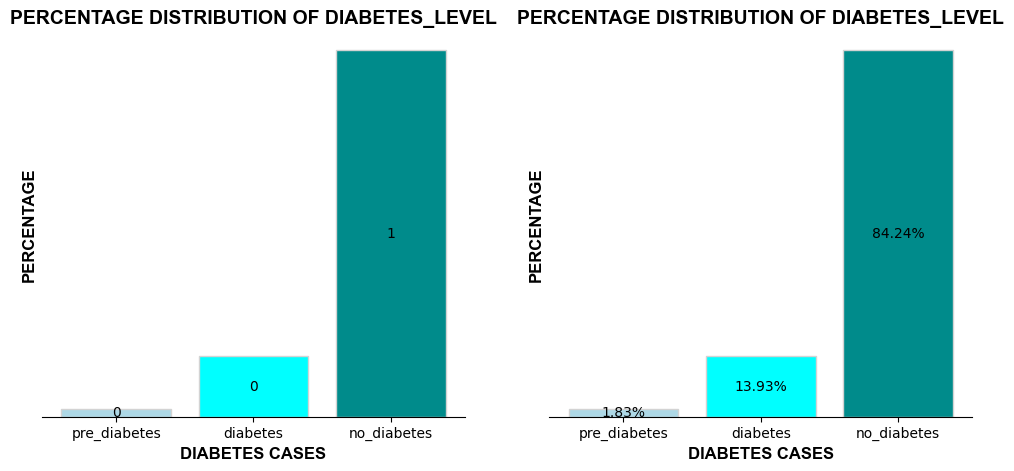

In [12]:
fig, axs = plt.subplots(
    figsize = (12, 5),
    ncols = 2
)

plot_df = dataset.group_by(
    ["DIABETES_LEVEL"]
).agg(
    pl.col("DIABETES_LEVEL").len().cast(pl.Int32).alias("TOTAL")
).with_columns(
    (pl.col("TOTAL")/pl.col("TOTAL").sum()).alias("PERCENTAGE")
).sort(
    "TOTAL"
)

for index, column in enumerate(["PERCENTAGE", "PERCENTAGE"]):

    plots.plot_bar(
        ax = axs[index],
        x_values = plot_df["DIABETES_LEVEL"],
        y_values = plot_df[column],
        colors = ["lightblue", "cyan", "darkcyan"],
        legends = plot_df["DIABETES_LEVEL"],
        formater = ["{:,.0f}", "{:,.2%}"][index],
        title = {
            "text": f"{column} DISTRIBUTION OF DIABETES_LEVEL",
            "font": "arial",
            "size": 14,
        },
        x_label = {
            "text": "DIABETES CASES",
            "font": "arial",
            "size": 12,
        },
        y_label = {
            "text": column,
            "font": "arial",
            "size": 12
        }   
    )

plt.show()

### 3.1) Correlations

<p>According to the interpretation of the module of index correlation bellow:</p>

<ul>
    <li><b>0.00 - 0.10</b>: no correlation;</li>
    <li><b>0.10 - 0.30</b>: small correlation;</li>
    <li><b>0.30 - 0.50</b>: moderate correlation;</li>
    <li><b>0.50 - 0.70</b>: strong correlation;</li>
    <li><b>0.70 - 1.00</b>: high correlation;</li>
</ul>

<p>We do not find bellow a single value between the range <b><mrow>[0.70, 1.00]</mrow></b>, with indicate us that all features are kind unique. Therefore, we will not drop any feature.</p>

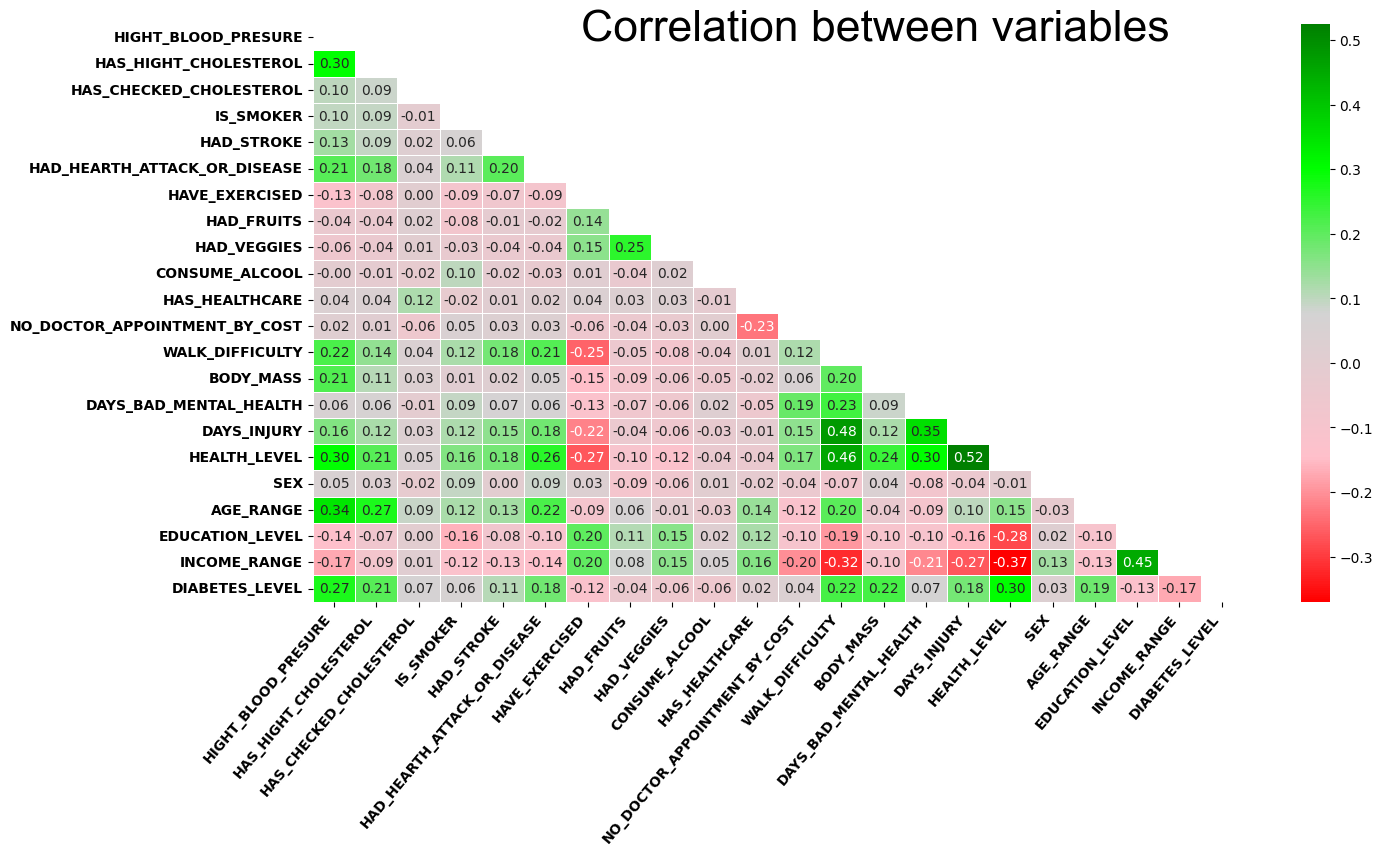

In [13]:
fig, ax = plt.subplots(
    figsize = (15, 7.5),
)

corr_dataset = dataset.with_columns(
        pl.col(pl.Enum).to_physical()
    ).corr(),

sns.heatmap(
    data = corr_dataset[0],
    ax = ax,
    xticklabels = corr_dataset[0].columns,
    yticklabels = corr_dataset[0].columns,
    annot = True,
    fmt = ".2f",
    cmap = my_cmap,
    annot_kws = {"size": 10},
    linewidths = .5,
    mask = np.triu(
        np.ones_like(
            a = corr_dataset[0],
            dtype = bool
        )
    ),
)

ax.set_xticklabels(ax.get_xticklabels(), fontweight = 'bold', rotation = 50, ha = "right")
ax.set_yticklabels(ax.get_xticklabels(), fontweight = 'bold', rotation = 0)

plt.suptitle(
    t = "Correlation between variables",
    fontsize = 32,
    font = "Arial",
    y = .9
)

plt.show()

### 3.2) Importance Value (IV)

<p>Crea</p>

In [14]:
def calculate_iv(df, feature, target):

    stats = (
        df.group_by(feature)
        .agg([
            pl.col(target).filter(pl.col(target) == 0).count().alias("bons"),
            pl.col(target).filter(pl.col(target) == 1).count().alias("maus")
        ])
    )

    total_bons = stats["bons"].sum()
    total_maus = stats["maus"].sum()

    iv_df = stats.with_columns([
        (pl.col("bons") / total_bons).alias("prop_bons"),
        (pl.col("maus") / total_maus).alias("prop_maus")
    ]).with_columns(
        ( (pl.col("prop_bons") / pl.col("prop_maus")).log() ).alias("woe")
    ).with_columns(
        ( (pl.col("prop_bons") - pl.col("prop_maus")) * pl.col("woe") ).alias("iv_partial")
    )

    return iv_df["iv_partial"].sum()

In [15]:
calculate_iv(
    df = dataset,
    feature = "DAYS_BAD_MENTAL_HEALTH",
    target = "DIABETES_LEVEL"
)

ComputeError: cannot compare categorical with i32

This error occurred in the following expression:
	[(col("DIABETES_LEVEL")) == (dyn int: 1)]
while evaluating this larger expression:
	col("DIABETES_LEVEL").filter([(col("DIABETES_LEVEL")) == (dyn int: 1)]).count()


In [ ]:
dataset

HIGHT_BLOOD_PRESURE,HAS_HIGHT_CHOLESTEROL,HAS_CHECKED_CHOLESTEROL,IS_SMOKER,HAD_STROKE,HAD_HEARTH_ATTACK_OR_DISEASE,HAVE_EXERCISED,HAD_FRUITS,HAD_VEGGIES,CONSUME_ALCOOL,HAS_HEALTHCARE,NO_DOCTOR_APPOINTMENT_BY_COST,WALK_DIFFICULTY,BODY_MASS,DAYS_BAD_MENTAL_HEALTH,DAYS_INJURY,HEALTH_LEVEL,SEX,AGE_RANGE,EDUCATION_LEVEL,INCOME_RANGE,DIABETES_LEVEL
bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f16,i8,i8,enum,enum,enum,enum,enum,enum
true,true,true,true,false,false,false,false,true,false,true,false,true,40.0,18,15,"""poor""","""female""","""60_64""","""high_school_completed""","""15k_20k""","""no_diabetes"""
false,false,false,true,false,false,true,false,false,false,false,true,false,25.0,0,0,"""good""","""female""","""50_54""","""college_graduate_completed""","""10k_less""","""no_diabetes"""
true,true,true,false,false,false,false,true,false,false,true,true,true,28.0,30,30,"""poor""","""female""","""60_64""","""high_school_completed""","""75K_more""","""no_diabetes"""
true,false,true,false,false,false,true,true,true,false,true,false,false,27.0,0,0,"""very_good""","""female""","""70_74""","""high_school_incompleted""","""35k_50k""","""no_diabetes"""
true,true,true,false,false,false,true,true,true,false,true,false,false,24.0,3,0,"""very_good""","""female""","""70_74""","""college_graduate_incompleted""","""20k_25k""","""no_diabetes"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
true,true,true,false,false,false,false,true,true,false,true,false,false,45.0,0,5,"""good""","""male""","""40_44""","""college_graduate_completed""","""50k_75k""","""no_diabetes"""
true,true,true,false,false,false,false,false,false,false,true,false,true,18.0,0,0,"""fair""","""female""","""70_74""","""elementary""","""20k_25k""","""diabetes"""
false,false,true,false,false,false,true,true,false,false,true,false,false,28.0,0,0,"""excelent""","""female""","""25_29""","""college_graduate_incompleted""","""10K_15k""","""no_diabetes"""
